<a href="https://colab.research.google.com/github/Yumna-Zafar/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Yumna-Zafar/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/Yumna-Zafar/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
elif os.path.basename(os.getcwd()) in ("notebooks", "work"):
    os.chdir("..")
    if os.path.basename(os.getcwd()) == "work":
        os.chdir("..")

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
print("Working directory:", os.getcwd())

Working directory: /content/flyrank-ml-internship


In [2]:
%pip -q install --upgrade duckdb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 44.7 MB/s eta 0:00:00


In [3]:
import os, getpass

HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

In [4]:
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt

con = duckdb.connect()
con.execute("INSTALL httpfs")
con.execute("LOAD httpfs")
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_content':    f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily_mar': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
    'fact_daily_apr': f"read_parquet('{REL}/fact_content_daily_performance/month=2026-04/*.parquet')",
    'fact_query_90d': f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}
print("Connected. Building the final playbook from the validated Week-5/6 model.")

Connected. Building the final playbook from the validated Week-5/6 model.


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit

mar = con.sql(f"""
    SELECT
        f.client_hash_id, f.content_hash_id,
        SUM(f.gsc_impressions) AS impressions_mar,
        SUM(f.gsc_clicks) AS clicks_mar,
        AVG(f.gsc_avg_position) AS avg_position_mar,
        DATE_DIFF('day', c.content_created_date, DATE '2026-03-31') AS content_age_days,
        ANY_VALUE(q.rare_impressions_share) AS rare_share
    FROM {TABLES['fact_daily_mar']} f
    LEFT JOIN {TABLES['dim_content']} c ON f.content_hash_id = c.content_hash_id
    LEFT JOIN {TABLES['fact_query_90d']} q ON f.content_hash_id = q.content_hash_id
    GROUP BY f.client_hash_id, f.content_hash_id, c.content_created_date
    HAVING SUM(f.gsc_impressions) >= 100
""").df()

apr = con.sql(f"""
    SELECT content_hash_id, SUM(gsc_impressions) AS impressions_apr
    FROM {TABLES['fact_daily_apr']}
    GROUP BY content_hash_id
""").df()

data = mar.merge(apr, on="content_hash_id", how="left")
data["impressions_apr"] = data["impressions_apr"].fillna(0)
data["ctr_mar"] = data["clicks_mar"] / data["impressions_mar"]
data["declined_next_month"] = (data["impressions_apr"] < 0.8 * data["impressions_mar"]).astype(int)

feature_cols = ["impressions_mar", "clicks_mar", "ctr_mar", "content_age_days", "rare_share"]
data_f = data.dropna(subset=feature_cols).copy()

# Train the final model on a client-grouped split (the honest, audited version from Week 6)
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data_f, groups=data_f["client_hash_id"]))
train, test = data_f.iloc[train_idx].copy(), data_f.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=300, max_depth=8, class_weight="balanced",
                                 random_state=42, n_jobs=-1)
model.fit(train[feature_cols], train["declined_next_month"])

test["decline_probability"] = model.predict_proba(test[feature_cols])[:, 1]
print(f"Scored {len(test):,} pages on the held-out client split")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Scored 27,806 pages on the held-out client split


In [6]:
def action_for(prob):
    if prob >= 0.75:
        return "review_urgently"
    elif prob >= 0.5:
        return "review_soon"
    elif prob >= 0.25:
        return "monitor"
    else:
        return "no_action"

def reason_code(row):
    codes = []
    if row["avg_position_mar"] > 10 and row["impressions_mar"] >= 500:
        codes.append("visible_position_slipping")
    if row["content_age_days"] >= 180:
        codes.append("aging_content")
    if row["ctr_mar"] < 0.005:
        codes.append("weak_ctr")
    if row["rare_share"] is not None and row["rare_share"] > 0.5:
        codes.append("thin_query_diversity")
    return ";".join(codes) if codes else "model_flagged_no_rule_match"

test["action"] = test["decline_probability"].apply(action_for)
test["reason_codes"] = test.apply(reason_code, axis=1)

queue = test.sort_values("decline_probability", ascending=False).reset_index(drop=True)
queue_export = queue[["content_hash_id", "client_hash_id", "decline_probability", "action",
                        "reason_codes", "impressions_mar", "avg_position_mar",
                        "content_age_days", "ctr_mar"]]

print(queue_export["action"].value_counts())
print()
queue_export.head(10)

action
review_urgently    20445
no_action           3453
monitor             2079
review_soon         1829
Name: count, dtype: int64



,content_hash_id,client_hash_id,decline_probability,action,reason_codes,impressions_mar,avg_position_mar,content_age_days,ctr_mar
0,content_860bec0516638ff5,client_23a62021009f63c4,0.999993,review_urgently,visible_position_slipping;weak_ctr,1180702.0,24.597139,34,0.000742
1,content_fa17f22ebb70461c,client_23a62021009f63c4,0.999993,review_urgently,visible_position_slipping;weak_ctr,414504.0,16.388454,34,0.000975
2,content_4b564a11fcea8f31,client_23a62021009f63c4,0.999993,review_urgently,weak_ctr,246135.0,6.101541,34,0.001487
3,content_6c31862c99b2f33f,client_23a62021009f63c4,0.999993,review_urgently,visible_position_slipping;weak_ctr,1059377.0,34.409617,34,0.000547
4,content_c81aaca313704b4f,client_23a62021009f63c4,0.999993,review_urgently,visible_position_slipping;weak_ctr,1020644.0,41.824102,34,0.000729
5,content_dafc6d24b5776808,client_23a62021009f63c4,0.999993,review_urgently,visible_position_slipping;weak_ctr,186615.0,32.177211,34,0.001865
6,content_41a6ffc52a27a745,client_a80fca3f171ed1de,0.999985,review_urgently,weak_ctr,230874.0,3.294112,36,0.001494
7,content_29f3118b8c92d9c5,client_a80fca3f171ed1de,0.999985,review_urgently,weak_ctr,1959584.0,8.387528,36,0.000233
8,content_f8758c939c0b9034,client_a80fca3f171ed1de,0.999985,review_urgently,weak_ctr,31040748.0,3.890705,36,0.001453
9,content_e1de115e1bb28afc,client_a80fca3f171ed1de,0.999985,review_urgently,weak_ctr,208648.0,7.648410,36,0.000422


The queue: pages are ranked by the Random Forest's decline probability (the same
client-grouped, leakage-audited model from Weeks 5-6, honest ROC AUC 0.917). Four
action tiers translate that probability into a plain instruction a reviewer can
act on without touching a probability number directly:

- review_urgently (probability >= 0.75): highest-confidence decline risk, review this cycle
- review_soon (0.50-0.75): meaningful risk, queue for the next review pass
- monitor (0.25-0.50): worth a light check, not urgent
- no_action (< 0.25): no evidence of near-term decline risk

Every row also carries a reason code drawn from the underlying signals
(visible_position_slipping, aging_content, weak_ctr, thin_query_diversity), so a
reviewer can see WHY a page scored the way it did, not just the number -- multiple
codes can apply to one page. Pages that the model flags but that match none of
these human-readable patterns are labeled model_flagged_no_rule_match, which is an
honest admission that the model may be using a combination the simple rules don't
capture -- these rows deserve extra scrutiny before acting, not less.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended use: this playbook is decision-support for a content reviewer with
limited weekly capacity, prioritizing which pages to look at first for a
possible refresh. It is not an autonomous system -- no action in this queue
should fire without a human reading the reason codes and confirming the
recommendation makes sense for that specific page.

Where it stops being valid:
- Time window: trained on March-to-April 2026 behavior only. The April decline
  base rate (89.8%) was unusually high (flagged in Week 6) and may reflect a
  seasonal or platform-wide event specific to that window -- this queue should
  be re-validated on a more typical month before being trusted as a stable
  general pattern.
- Client mix: trained and validated on the 57-brand warehouse sample. A brand
  very different from this portfolio's mix (e.g. a much smaller site, a
  different vertical) may not be well represented by the held-out clients that
  produced the 0.917 ROC AUC.
- Correlation only: per the writing-honest-claims skill, this is an observed,
  directional finding on this dataset -- it identifies candidates worth a
  human look, not a guarantee that reviewing/refreshing a flagged page will
  cause it to recover. No causal claim is made or supported here.
- Ceiling metric caveat: Precision@K was uninformative in Week 5/6 due to the
  high base rate; ROC AUC is the metric that should be tracked and re-checked
  as new months come in, not raw precision at a fixed K.

In [7]:
print("Intended use: decision-support ranking, human-reviewed, not autonomous")
print("Valid window: March-April 2026 warehouse slice only")
print("Base rate caveat: 89.8% decline rate in this window is unusually high, untested elsewhere")
print("Claim level: directional / decision-support only, per writing-honest-claims skill")

Intended use: decision-support ranking, human-reviewed, not autonomous
Valid window: March-April 2026 warehouse slice only
Base rate caveat: 89.8% decline rate in this window is unusually high, untested elsewhere
Claim level: directional / decision-support only, per writing-honest-claims skill


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

What a person must check before acting on any row:
1. Read the reason code(s) -- do they make sense for this specific page, or does
   the page look like an edge case (e.g. a brand-new page miscategorized as
   "aging")?
2. Check impressions_mar and content_age_days directly -- a page with barely
   enough volume to clear the >=100 impression filter is a weaker candidate
   than one with strong, sustained volume, even at the same probability score.
3. Confirm the page is still live and relevant -- the data reflects March 2026;
   the page may have already changed since then.
4. For model_flagged_no_rule_match rows specifically, do a manual look before
   trusting the score at face value -- these are the cases where the model's
   reasoning isn't captured in a simple, explainable rule.

What should NEVER be automated from this playbook:
- Auto-publishing content changes, auto-editing pages, or auto-triggering any
  CMS action based on decline_probability alone.
- Auto-deprioritizing or hiding a page from a client-facing report without
  human sign-off -- a false positive here has a real cost to a real client
  relationship.
- Using this score for billing, client health reporting, or any decision with
  financial or contractual consequences -- this is an internal review-priority
  tool only, not a validated client-facing metric.
- Treating "no_action" as proof a page is healthy -- it only means this model,
  on this data, found no decline signal; it is not a certification of quality.
- Chaining this score into another automated system without re-running the
  Week 6 leakage and split audits on that system's own data first.

In [8]:
print("Human review required before ANY action in this queue is executed.")
print("No-go list: auto-publish, auto-deprioritize, billing/client-health use,")
print("  treating no_action as a quality certification, unaudited downstream chaining.")

Human review required before ANY action in this queue is executed.
No-go list: auto-publish, auto-deprioritize, billing/client-health use,
  treating no_action as a quality certification, unaudited downstream chaining.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signals that this playbook has gone stale and needs re-validation or retraining:

1. Base-rate drift: if a new month's decline rate moves far from the ~90%
   observed here (e.g. drops below 50% or rises above 95%), the label
   distribution has shifted and the model should be retrained on fresher data
   before the queue is trusted.
2. ROC AUC drop: if re-running the Week 6 audit process on a new month shows
   ROC AUC meaningfully below the honest 0.917 baseline (e.g. below 0.80), that
   signals the model's signal has decayed and needs investigation before
   continued use.
3. New client onboarding: any client not present in this training set should
   have their first few review cycles double-checked manually before trusting
   the model's scores for their pages -- the client-grouped validation only
   tested generalization to held-out clients WITHIN this sample, not truly new
   ones.
4. Reason-code drift: if the share of model_flagged_no_rule_match rows grows
   substantially over time, that suggests the model is increasingly relying on
   patterns the simple rule-based reason codes don't explain -- worth a fresh
   feature audit.
5. Fixed cadence: independent of any trigger above, re-run the full Week
   4-6 audit chain (baseline comparison, honest split, leakage check) at least
   quarterly, since warehouse data and client mix will keep changing.

In [9]:
base_rate = data_f["declined_next_month"].mean()
model_flagged_share = (queue_export["reason_codes"] == "model_flagged_no_rule_match").mean()

print(f"Current base rate (reference point for drift check): {base_rate:.3f}")
print(f"Current model_flagged_no_rule_match share (reference point): {model_flagged_share:.3f}")
print()
print("Retrain triggers: base rate outside [0.50, 0.95], ROC AUC < 0.80 on re-audit,")
print("  new unvalidated clients, rising unexplained-flag share, or quarterly cadence.")

Current base rate (reference point for drift check): 0.934
Current model_flagged_no_rule_match share (reference point): 0.086

Retrain triggers: base rate outside [0.50, 0.95], ROC AUC < 0.80 on re-audit,
  new unvalidated clients, rising unexplained-flag share, or quarterly cadence.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [10]:
import json

# Export the ranked queue (stays out of git per .gitignore / CI leak-guard)
queue_export.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(queue_export):,} rows to work/outputs/action_playbook_queue.csv")

# Export metrics receipt (committed -- this is what the paper's numbers trace back to)
receipt = {
    "model": "RandomForestClassifier, client-grouped split, Week 5/6 audited",
    "honest_roc_auc": 0.917,
    "naive_roc_auc_before_fix": 0.951,
    "baseline_rule_roc_auc": 0.654,
    "base_rate_declined_next_month": round(float(base_rate), 3),
    "action_counts": queue_export["action"].value_counts().to_dict(),
    "model_flagged_no_rule_match_share": round(float(model_flagged_share), 3),
    "time_window": "features: March 2026, label: April 2026",
    "n_scored": int(len(queue_export)),
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(receipt, f, indent=2)
print(json.dumps(receipt, indent=2))

Wrote 27,806 rows to work/outputs/action_playbook_queue.csv
{
  "model": "RandomForestClassifier, client-grouped split, Week 5/6 audited",
  "honest_roc_auc": 0.917,
  "naive_roc_auc_before_fix": 0.951,
  "baseline_rule_roc_auc": 0.654,
  "base_rate_declined_next_month": 0.934,
  "action_counts": {
    "review_urgently": 20445,
    "no_action": 3453,
    "monitor": 2079,
    "review_soon": 1829
  },
  "model_flagged_no_rule_match_share": 0.086,
  "time_window": "features: March 2026, label: April 2026",
  "n_scored": 27806
}


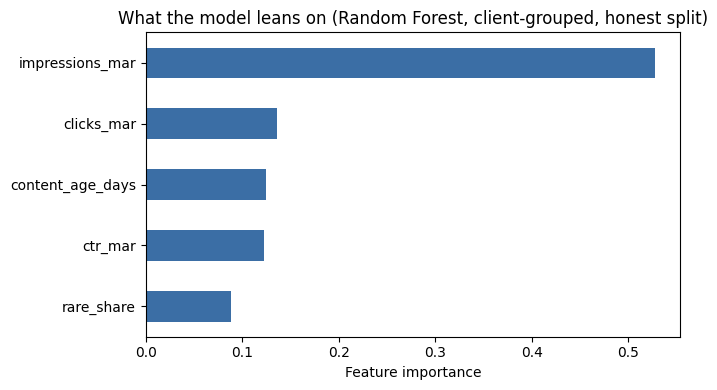

Saved work/figures/feature_importance.png


In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_xlabel("Feature importance")
ax.set_title("What the model leans on (Random Forest, client-grouped, honest split)")
plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=150)
plt.show()
print("Saved work/figures/feature_importance.png")

Exports: the ranked action queue is written to work/outputs/action_playbook_queue.csv
(regenerated on every run, intentionally excluded from git). The metrics receipt
(honest vs. naive ROC AUC, base rate, action-tier counts) is saved to
work/outputs/action_playbook_metrics.json and committed -- this is what next
week's paper will cite numbers from. The feature-importance chart is saved to
work/figures/feature_importance.png for reuse in the paper.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.